In [1]:
# importing libraries 
import numpy as np
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [3]:
# Loading model

cnn = tf.keras.models.load_model('/Users/kotireddy/Desktop/deepfritveg_identificatiion/models/fruit_model.h5')


2025-11-09 23:26:59.492623: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-11-09 23:26:59.492654: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-11-09 23:26:59.492678: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-11-09 23:26:59.492956: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-09 23:26:59.492988: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


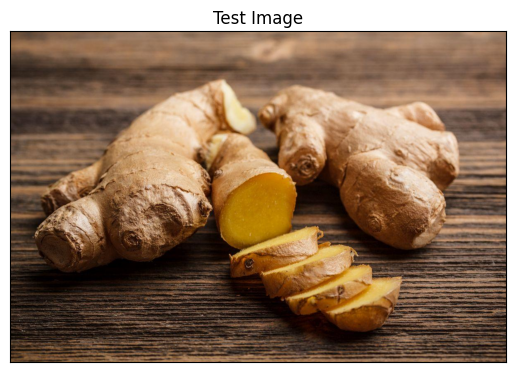

In [4]:
# Visualising and Performing Prediction on Single image

#Test Image Visualization
import cv2
image_path = '/Users/kotireddy/Desktop/deepfritveg_identificatiion/fruit veg data set master/test/ginger/Image_1.jpg'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [5]:
# Testing Model

image = tf.keras.preprocessing.image.load_img(image_path,target_size=(64,64))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

2025-11-09 23:27:21.018559: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 876ms/step


In [6]:
print(predictions[0])
print(max(predictions[0]))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1.0


In [7]:

test_set = tf.keras.utils.image_dataset_from_directory(
    '/Users/kotireddy/Desktop/deepfritveg_identificatiion/fruit veg data set master/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 3115 files belonging to 36 classes.


In [8]:
test_set.class_names

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [9]:
result_index = np.where(predictions[0] ==max(predictions[0]))#Return index of max element
print(result_index[0][0])

13


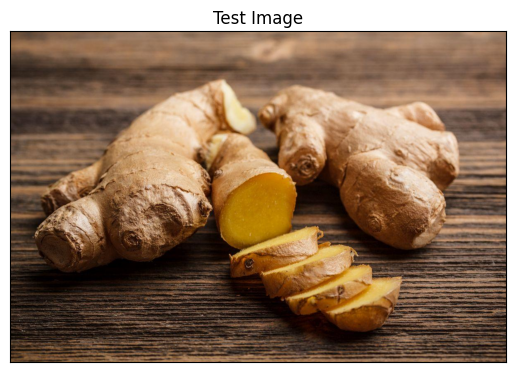

In [10]:
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [11]:
#Single image Prediction
print("It's a {}".format(test_set.class_names[result_index[0][0]]))

It's a ginger


In [12]:
with open("labels.txt", "w") as file:
    for i in test_set.class_names:
        file.write(i + '\n')


In [13]:
with open("labels.txt") as f:
    print(f.read())


apple
banana
beetroot
bell pepper
cabbage
capsicum
carrot
cauliflower
chilli pepper
corn
cucumber
eggplant
garlic
ginger
grapes
jalepeno
kiwi
lemon
lettuce
mango
onion
orange
paprika
pear
peas
pineapple
pomegranate
potato
raddish
soy beans
spinach
sweetcorn
sweetpotato
tomato
turnip
watermelon

